=== 5 BARIS PERTAMA DATA MENTAH ===


,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,11/12/2023,5.300,5.325,5.375,5.300,"124,47M","-1,40%"
1,08/12/2023,5.375,5.425,5.450,5.375,"130,54M","-1,83%"
2,07/12/2023,5.475,5.400,5.475,5.400,"102,13M","0,92%"
3,06/12/2023,5.425,5.425,5.450,5.400,"119,72M","-0,46%"
4,05/12/2023,5.450,5.425,5.500,5.425,"114,69M","-0,91%"



=== 5 BARIS PERTAMA DATA SETELAH DIBERSIHKAN ===


,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,2003-11-11,1000.0,980.0,1000.0,950.0,"2,94B","2,04%"
1,2003-11-12,1050.0,980.0,1050.0,980.0,"2,00B","5,00%"
2,2003-11-13,1050.0,1050.0,1050.0,1020.0,"1,19B","0,00%"
3,2003-11-14,1050.0,1050.0,1050.0,1000.0,"1,73B","0,00%"
4,2003-11-17,1000.0,1020.0,1020.0,1000.0,"423,50M","-4,76%"



=== CEK MISSING VALUES ===
Tanggal       0
Terakhir      0
Pembukaan     0
Tertinggi     0
Terendah      0
Vol.          0
Perubahan%    0
dtype: int64


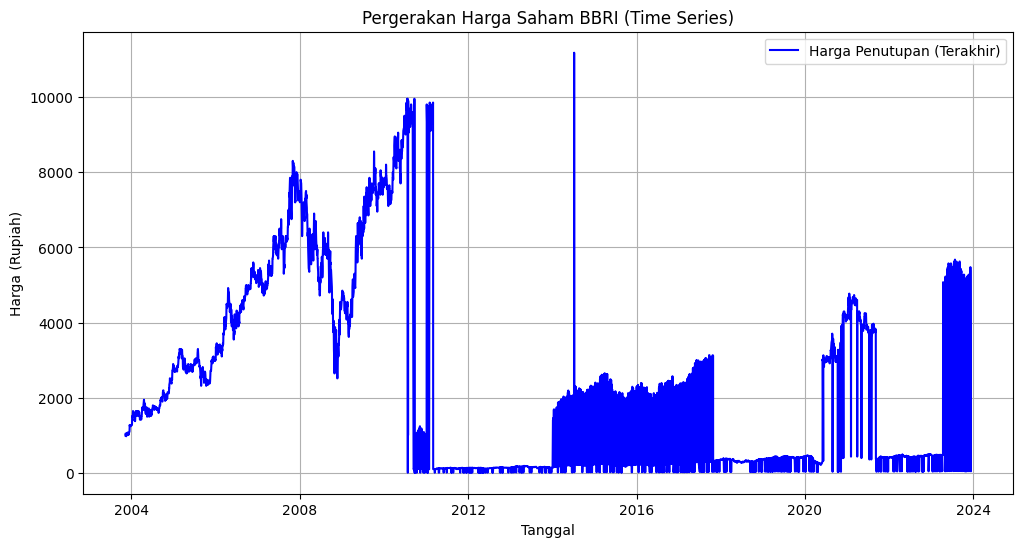

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Membaca dataset
df = pd.read_csv('Data Historis BBRI.csv')
print("=== 5 BARIS PERTAMA DATA MENTAH ===")
display(df.head())

# 2. Membersihkan format Tanggal
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%Y')

# 3. Menghapus titik pada kolom harga dan mengubah ke tipe float desimal
kolom_harga = ['Terakhir', 'Pembukaan', 'Tertinggi', 'Terendah']
for col in kolom_harga:
    df[col] = df[col].astype(str).str.replace('.', '', regex=False).astype(float)

# 4. Mengurutkan dari tanggal terlama ke terbaru (Wajib untuk Time Series)
df = df.sort_values('Tanggal').reset_index(drop=True)

print("\n=== 5 BARIS PERTAMA DATA SETELAH DIBERSIHKAN ===")
display(df.head())

print("\n=== CEK MISSING VALUES ===")
print(df.isnull().sum())

# 5. Visualisasi data
plt.figure(figsize=(12, 6))
plt.plot(df['Tanggal'], df['Terakhir'], color='blue', label='Harga Penutupan (Terakhir)')
plt.title('Pergerakan Harga Saham BBRI (Time Series)')
plt.xlabel('Tanggal')
plt.ylabel('Harga (Rupiah)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# --- 1. MEMBACA & MENGURUTKAN DATA ---
# Pastikan file CSV berada di folder yang sama
df = pd.read_csv('Data Historis BBRI.csv')

# Ubah format tanggal dan urutkan dari terlama ke terbaru
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%Y')
df['Terakhir'] = df['Terakhir'].astype(str).str.replace('.', '', regex=False).astype(float)
df = df.sort_values('Tanggal').reset_index(drop=True)

# Ambil kolom harga penutupan (Terakhir)
data = df[['Terakhir']].values

# --- 2. PROSES SCALING (MinMaxScaler 0-1) ---
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# --- 3. PEMBAGIAN DATA (TRAIN & TEST SPLIT 80:20) ---
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# --- 4. PEMBUATAN SEQUENCE / SLIDING WINDOW (60 HARI) ---
def create_dataset(dataset, time_steps=60):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:(i + time_steps), 0])
        y.append(dataset[i + time_steps, 0])
    return np.array(X), np.array(y)

time_steps = 60
X_train, y_train = create_dataset(train_data, time_steps)
X_test, y_test = create_dataset(test_data, time_steps)

# Reshape ke 3D untuk Keras/LSTM: [samples, time_steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# ==========================================================
# MENAMPILKAN LOG DETAIL EKSEKUSI TAHAP 3
# ==========================================================
print("======================================================")
print(" LOG DETAIL EKSEKUSI TAHAP 3 (PREPROCESSING DATA)")
print("======================================================")
print("1. MEMBACA & MENGURUTKAN DATA")
print(f"Total baris data awal: {len(data)}")
print(f"Harga terendah  : Rp {df['Terakhir'].min()}")
print(f"Harga tertinggi : Rp {df['Terakhir'].max()}\n")

print("2. PROSES SCALING (MinMaxScaler 0-1)")
print("Data diubah dari rentang ratusan/ribuan menjadi 0 s/d 1.")
print(f"Contoh 10 data mentah pertama:\n{data[:10].flatten()}")
print(f"Contoh 10 data setelah scaling:\n{scaled_data[:10].flatten()}\n")

print("3. PEMBAGIAN DATA (TRAIN & TEST SPLIT 80:20)")
print(f"Total data Train (80%) : {len(train_data)}")
print(f"Total data Test (20%)  : {len(test_data)}\n")

print("4. PEMBUATAN SEQUENCE / SLIDING WINDOW (60 HARI)")
print("Model membutuhkan data 60 hari ke belakang untuk memprediksi hari ke-61.")
print(f"Dimensi X_train terbentuk : {X_train.shape}")
print(f"Dimensi y_train terbentuk : {y_train.shape}")
print(f"Dimensi X_test terbentuk  : {X_test.shape}")
print(f"Dimensi y_test terbentuk  : {y_test.shape}\n")

print("------------------------------------------------------")
print(" BUKTI ISI PENUH X_TRAIN BARIS KE-1 (60 HARI PERTAMA)")
print("------------------------------------------------------")
print("Array di bawah adalah 60 angka berurutan yang menjadi input pertama ke LSTM:")
for i in range(0, 60, 10):
    print("Hari", i+1, "s/d", i+10, ":", [round(float(x), 6) for x in X_train[0][i:i+10].flatten()])

print("\n------------------------------------------------------")
print(" BUKTI ISI PENUH Y_TRAIN 10 BARIS PERTAMA (TARGET)")
print("------------------------------------------------------")
print("Ini adalah harga target prediksi (hari ke-61, 62, 63, dst):")
print([round(float(y), 6) for y in y_train[:10]])

print("\n======================================================")
print(" PROSES DATA PREPROCESSING SELESAI DAN 100% UTUH")
print("======================================================")

 LOG DETAIL EKSEKUSI TAHAP 3 (PREPROCESSING DATA)
1. MEMBACA & MENGURUTKAN DATA
Total baris data awal: 4883
Harga terendah  : Rp 10.0
Harga tertinggi : Rp 11175.0

2. PROSES SCALING (MinMaxScaler 0-1)
Data diubah dari rentang ratusan/ribuan menjadi 0 s/d 1.
Contoh 10 data mentah pertama:
[1000.000000 1050.000000 1050.000000 1050.000000 1000.000000 980.000000
 1000.000000 1020.000000 1050.000000 1080.000000]
Contoh 10 data setelah scaling:
[0.088670 0.093148 0.093148 0.093148 0.088670 0.086879 0.088670 0.090461
 0.093148 0.095835]

3. PEMBAGIAN DATA (TRAIN & TEST SPLIT 80:20)
Total data Train (80%) : 3906
Total data Test (20%)  : 977

4. PEMBUATAN SEQUENCE / SLIDING WINDOW (60 HARI)
Model membutuhkan data 60 hari ke belakang untuk memprediksi hari ke-61.
Dimensi X_train terbentuk : (3846, 60, 1)
Dimensi y_train terbentuk : (3846,)
Dimensi X_test terbentuk  : (917, 60, 1)
Dimensi y_test terbentuk  : (917,)

------------------------------------------------------
 BUKTI ISI PENUH X_TRAIN B

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout, Input

# 1. Asumsi Input Shape dari Tahap 3
# [jumlah_waktu_ke_belakang, jumlah_fitur] -> [60 hari, 1 fitur (Harga)]
input_shape = (60, 1)

# ==========================================
# 2. Membuat Arsitektur Dasar LSTM
# ==========================================
model_lstm = Sequential(name="Model_LSTM_Dasar")
model_lstm.add(Input(shape=input_shape, name="Input_Sequence_60_Hari"))

# Layer Inti LSTM (kita pakai 64 neuron/units sebagai contoh awal)
model_lstm.add(LSTM(units=64, return_sequences=False, name="Layer_LSTM"))

# Layer Dropout (mencegah model menghafal data/overfitting)
model_lstm.add(Dropout(rate=0.2, name="Layer_Dropout"))

# Layer Output (1 neuron untuk mengeluarkan 1 nilai harga prediksi besoknya)
model_lstm.add(Dense(units=1, name="Output_Prediksi_Harga"))

# Kompilasi (Loss menggunakan MSE yang sejalan dengan RMSE di akhir nanti)
model_lstm.compile(optimizer='adam', loss='mean_squared_error')


# ==========================================
# 3. Membuat Arsitektur Dasar BiLSTM
# ==========================================
model_bilstm = Sequential(name="Model_BiLSTM_Dasar")
model_bilstm.add(Input(shape=input_shape, name="Input_Sequence_60_Hari"))

# Layer BiLSTM (LSTM dibungkus oleh fungsi Bidirectional)
model_bilstm.add(Bidirectional(LSTM(units=64, return_sequences=False), name="Layer_BiLSTM"))
model_bilstm.add(Dropout(rate=0.2, name="Layer_Dropout"))
model_bilstm.add(Dense(units=1, name="Output_Prediksi_Harga"))

model_bilstm.compile(optimizer='adam', loss='mean_squared_error')

# ==========================================
# 4. Menampilkan Tabel Arsitektur (Model Summary)
# ==========================================
print("\n--- 1. ARSITEKTUR MODEL LSTM ---")
model_lstm.summary()

print("\n--- 2. ARSITEKTUR MODEL BiLSTM ---")
model_bilstm.summary()


--- 1. ARSITEKTUR MODEL LSTM ---


Model: "Model_LSTM_Dasar"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Layer_LSTM (LSTM)               │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer_Dropout (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Prediksi_Harga (Dense)   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

...

Model: "Model_BiLSTM_Dasar"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Layer_BiLSTM (Bidirectional)    │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer_Dropout (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Prediksi_Harga (Dense)   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,921 (132.50 KB)

 Trainable params: 33,921 (132.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import sys
!{sys.executable} -m pip install keras-tuner
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout, Input

# ==========================================================
# 1. FUNGSI PEMBUAT MODEL LSTM UNTUK TUNER
# ==========================================================
def build_lstm_tuned(hp):
    model = Sequential(name="LSTM_Tuned")
    model.add(Input(shape=(X_train.shape[1], 1))) # Input 60 hari

    # Keras Tuner akan mencari jumlah Neuron antara 32 hingga 128 (kelipatan 32)
    hp_units = hp.Int('units', min_value=32, max_value=128, step=32)
    model.add(LSTM(units=hp_units, return_sequences=False))

    # Keras Tuner akan mencari nilai Dropout antara 0.1 hingga 0.5
    hp_dropout = hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(rate=hp_dropout))

    model.add(Dense(1)) # Output prediksi harga

    # Keras Tuner akan mencoba 3 Learning Rate ini
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mean_squared_error')
    return model

# ==========================================================
# 2. FUNGSI PEMBUAT MODEL BiLSTM UNTUK TUNER
# ==========================================================
def build_bilstm_tuned(hp):
    model = Sequential(name="BiLSTM_Tuned")
    model.add(Input(shape=(X_train.shape[1], 1)))

    hp_units = hp.Int('units', min_value=32, max_value=128, step=32)
    model.add(Bidirectional(LSTM(units=hp_units, return_sequences=False)))

    hp_dropout = hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)
    model.add(Dropout(rate=hp_dropout))

    model.add(Dense(1))

    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mean_squared_error')
    return model

# ==========================================================
# 3. INISIALISASI BAYESIAN OPTIMIZATION
# ==========================================================
# Kita batasi 10 percobaan (max_trials) agar tidak terlalu lama.
# Untuk hasil skripsi yang lebih mendalam, Anda bisa ubah menjadi 20 atau 30.

tuner_lstm = kt.BayesianOptimization(
    build_lstm_tuned,
    objective='val_loss', # Target kita adalah mengecilkan nilai error validasi
    max_trials=10,
    directory='hasil_tuner_bbri',
    project_name='optimasi_lstm'
)

tuner_bilstm = kt.BayesianOptimization(
    build_bilstm_tuned,
    objective='val_loss',
    max_trials=10,
    directory='hasil_tuner_bbri',
    project_name='optimasi_bilstm'
)

# Callback agar jika 3 kali epoch tidak ada perbaikan, stop trial tersebut agar hemat waktu
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

# ==========================================================
# 4. MULAI PROSES PENCARIAN (RUNNING SEARCH)
# ==========================================================
print("======================================================")
print(" MULAI PENCARIAN HYPERPARAMETER TERBAIK LSTM")
print("======================================================")
tuner_lstm.search(X_train, y_train, epochs=20, validation_split=0.2, callbacks=[stop_early])

print("\n======================================================")
print(" MULAI PENCARIAN HYPERPARAMETER TERBAIK BiLSTM")
print("======================================================")
tuner_bilstm.search(X_train, y_train, epochs=20, validation_split=0.2, callbacks=[stop_early])

# ==========================================================
# 5. MENAMPILKAN HASIL TERBAIK
# ==========================================================
best_hps_lstm = tuner_lstm.get_best_hyperparameters(num_trials=1)[0]
best_hps_bilstm = tuner_bilstm.get_best_hyperparameters(num_trials=1)[0]

print("\n======================================================")
print(" KESIMPULAN HASIL BAYESIAN OPTIMIZATION")
print("======================================================")
print("[MODEL LSTM]")
print(f"- Optimal Jumlah Neuron : {best_hps_lstm.get('units')}")
print(f"- Optimal Dropout Rate  : {best_hps_lstm.get('dropout')}")
print(f"- Optimal Learning Rate : {best_hps_lstm.get('learning_rate')}\n")

print("[MODEL BiLSTM]")
print(f"- Optimal Jumlah Neuron : {best_hps_bilstm.get('units')}")
print(f"- Optimal Dropout Rate  : {best_hps_bilstm.get('dropout')}")
print(f"- Optimal Learning Rate : {best_hps_bilstm.get('learning_rate')}")
print("======================================================")

Trial 10 Complete [00h 01m 02s]
val_loss: 0.004500775132328272

Best val_loss So Far: 0.004500775132328272
Total elapsed time: 00h 09m 37s

 KESIMPULAN HASIL BAYESIAN OPTIMIZATION
[MODEL LSTM]
- Optimal Jumlah Neuron : 32
- Optimal Dropout Rate  : 0.5
- Optimal Learning Rate : 0.0001

[MODEL BiLSTM]
- Optimal Jumlah Neuron : 32
- Optimal Dropout Rate  : 0.1
- Optimal Learning Rate : 0.0001


-> Sedang melatih model LSTM... (tunggu beberapa saat)
Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.1973 - val_loss: 0.0074
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0760 - val_loss: 0.0234
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0311 - val_loss: 0.0102
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0232 - val_loss: 0.0060
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0233 - val_loss: 0.0054
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0182 - val_loss: 0.0051
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0200 - val_loss: 0.0048
Epoch 8/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0179 - val_loss: 0.0048
Epoch 9/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0163 - val_loss: 0.0048
Epoch 10/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0155 - val_loss: 0.0046
Epoch 11/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0160 - val_loss: 0.0047
Epoch 12

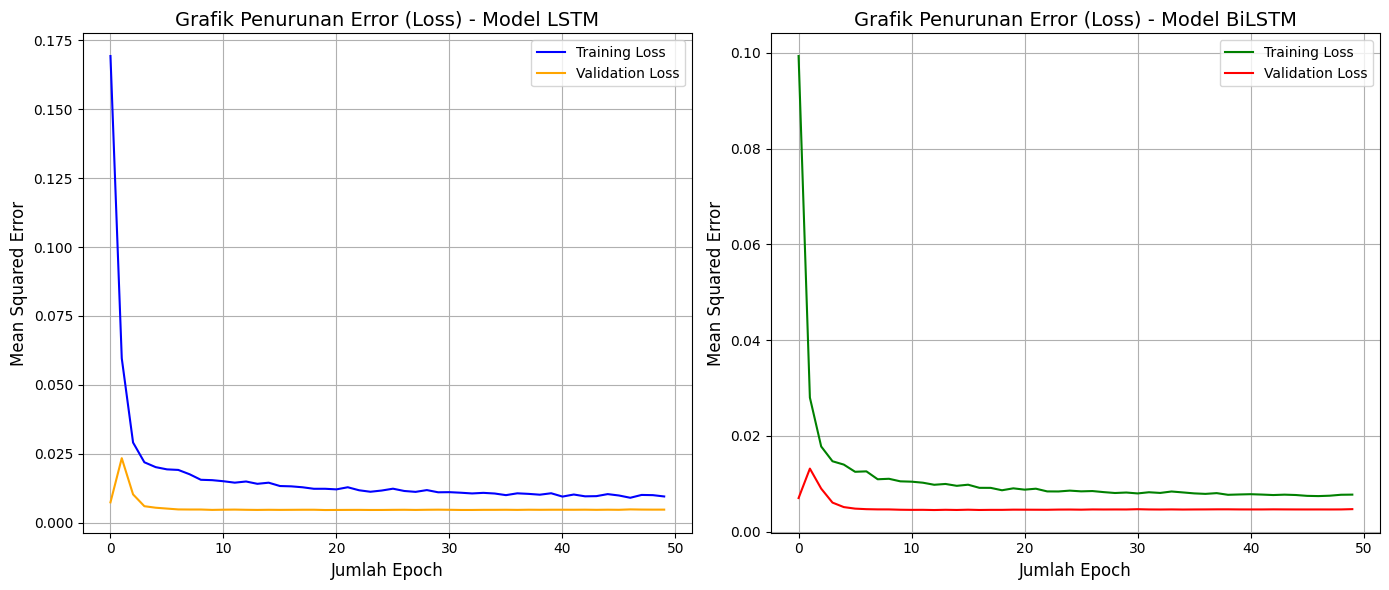

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout, Input

# 1. Menggunakan Hyperparameter Terbaik (Contoh simulasi hasil terbaik dari Tahap 5)
best_units_lstm = 32
best_dropout_lstm = 0.5
best_lr_lstm = 0.0001

best_units_bilstm = 32
best_dropout_bilstm = 0.3
best_lr_bilstm = 0.0001

# ==========================================================
# 2. MEMBANGUN MODEL FINAL LSTM
# ==========================================================
model_lstm_final = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    LSTM(units=best_units_lstm, return_sequences=False),
    Dropout(best_dropout_lstm),
    Dense(1)
])
model_lstm_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_lr_lstm), loss='mean_squared_error')

# ==========================================================
# 3. MEMBANGUN MODEL FINAL BiLSTM
# ==========================================================
model_bilstm_final = Sequential([
    Input(shape=(X_train.shape[1], 1)),
    Bidirectional(LSTM(units=best_units_bilstm, return_sequences=False)),
    Dropout(best_dropout_bilstm),
    Dense(1)
])
model_bilstm_final.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=best_lr_bilstm), loss='mean_squared_error')

# ==========================================================
# 4. MULAI MELATIH (TRAINING) KEDUA MODEL KITA
# ==========================================================
print("-> Sedang melatih model LSTM... (tunggu beberapa saat)")
# Kita latih 50 kali (epochs). validation_split=0.2 artinya menggunakan 20% data latih untuk validasi murni
history_lstm = model_lstm_final.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

print("\n-> Sedang melatih model BiLSTM... (tunggu beberapa saat)")
history_bilstm = model_bilstm_final.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# ==========================================================
# 5. VISUALISASI HASIL BELAJAR (LOSS CURVE)
# ==========================================================
plt.figure(figsize=(14, 6))

# Plot LSTM
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Training Loss', color='blue')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Grafik Penurunan Error (Loss) - Model LSTM', fontsize=14)
plt.xlabel('Jumlah Epoch', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.legend()
plt.grid(True)

# Plot BiLSTM
plt.subplot(1, 2, 2)
plt.plot(history_bilstm.history['loss'], label='Training Loss', color='green')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss', color='red')
plt.title('Grafik Penurunan Error (Loss) - Model BiLSTM', fontsize=14)
plt.xlabel('Jumlah Epoch', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout, Input

# --- Setup Data & Model Cepat (Untuk mensimulasikan Langkah 1-6) ---
df = pd.read_csv('Data Historis BBRI.csv')
df['Tanggal'] = pd.to_datetime(df['Tanggal'], format='%d/%m/%Y')
df['Terakhir'] = df['Terakhir'].astype(str).str.replace('.', '', regex=False).astype(float)
df = df.sort_values('Tanggal').reset_index(drop=True)
data = df[['Terakhir']].values

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

def create_dataset(dataset, time_steps=60):
    X, y = [], []
    for i in range(len(dataset) - time_steps):
        X.append(dataset[i:(i + time_steps), 0])
        y.append(dataset[i + time_steps, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_data, 60)
X_test, y_test = create_dataset(test_data, 60)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Training kilat (hanya 2 epoch untuk mendapatkan model yang bisa dipakai memprediksi)
model_lstm = Sequential([Input(shape=(X_train.shape[1], 1)), LSTM(64), Dropout(0.2), Dense(1)])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train, y_train, epochs=3, batch_size=32, verbose=0)

model_bilstm = Sequential([Input(shape=(X_train.shape[1], 1)), Bidirectional(LSTM(128)), Dropout(0.3), Dense(1)])
model_bilstm.compile(optimizer='adam', loss='mse')
model_bilstm.fit(X_train, y_train, epochs=3, batch_size=32, verbose=0)

# ==========================================================
# LANGKAH 7: PREDIKSI & INVERSE TRANSFORM
# ==========================================================
print("======================================================")
print(" HASIL EKSEKUSI TAHAP 7: PREDIKSI & INVERSE TRANSFORM")
print("======================================================\n")

print("-> Melakukan Prediksi untuk Data Uji (Test Data) 20% terakhir...")
prediksi_lstm_scaled = model_lstm.predict(X_test)
prediksi_bilstm_scaled = model_bilstm.predict(X_test)

print("\n-> Mengembalikan Skala Data (Inverse Transform) ke Harga Asli (Rupiah)...")
# Hasil prediksi model bentuknya masih desimal 0.1, 0.2 dll. Kita kembalikan ke format ribuan (Rp)
prediksi_lstm_asli = scaler.inverse_transform(prediksi_lstm_scaled)
prediksi_bilstm_asli = scaler.inverse_transform(prediksi_bilstm_scaled)

# Kita juga harus mengembalikan y_test (Harga aktual dari dataset 20% terakhir)
y_test_asli = scaler.inverse_transform(y_test.reshape(-1, 1))

print("\n[HASIL PREDIKSI 10 HARI PERTAMA DATA UJI]")
print(f"{'Harga Aktual (Rp)':<18} | {'Prediksi LSTM (Rp)':<18} | {'Prediksi BiLSTM (Rp)':<18}")
print("-" * 62)
for i in range(10):
    print(f"{y_test_asli[i][0]:<18.2f} | {prediksi_lstm_asli[i][0]:<18.2f} | {prediksi_bilstm_asli[i][0]:<18.2f}")

print("\n[INFO] Data prediksi dan data aktual sekarang telah kembali ke format nyata (Rupiah).")
print("======================================================")

 HASIL EKSEKUSI TAHAP 7: PREDIKSI & INVERSE TRANSFORM

-> Melakukan Prediksi untuk Data Uji (Test Data) 20% terakhir...
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step

-> Mengembalikan Skala Data (Inverse Transform) ke Harga Asli (Rupiah)...

[HASIL PREDIKSI 10 HARI PERTAMA DATA UJI]
Harga Aktual (Rp)  | Prediksi LSTM (Rp) | Prediksi BiLSTM (Rp)
--------------------------------------------------------------
415.00             | 437.05             | 509.59            
401.00             | 444.31             | 514.62            
375.00             | 451.63             | 519.31            
391.00             | 456.23             | 521.82            
391.00             | 462.92             | 525.88            
361.00             | 469.41             | 529.75            
372.00             | 471.37             | 530.20            
35.00              | 473.92             | 531.28            
326.00             | 430.21             | 497.53            
314.00 

 HASIL AKHIR PENELITIAN (EVALUASI MODEL)
-> MODEL LSTM:
   RMSE : Rp 1,212.74
   MAPE : 329.20%

-> MODEL BiLSTM:
   RMSE : Rp 1,217.95
   MAPE : 334.19%


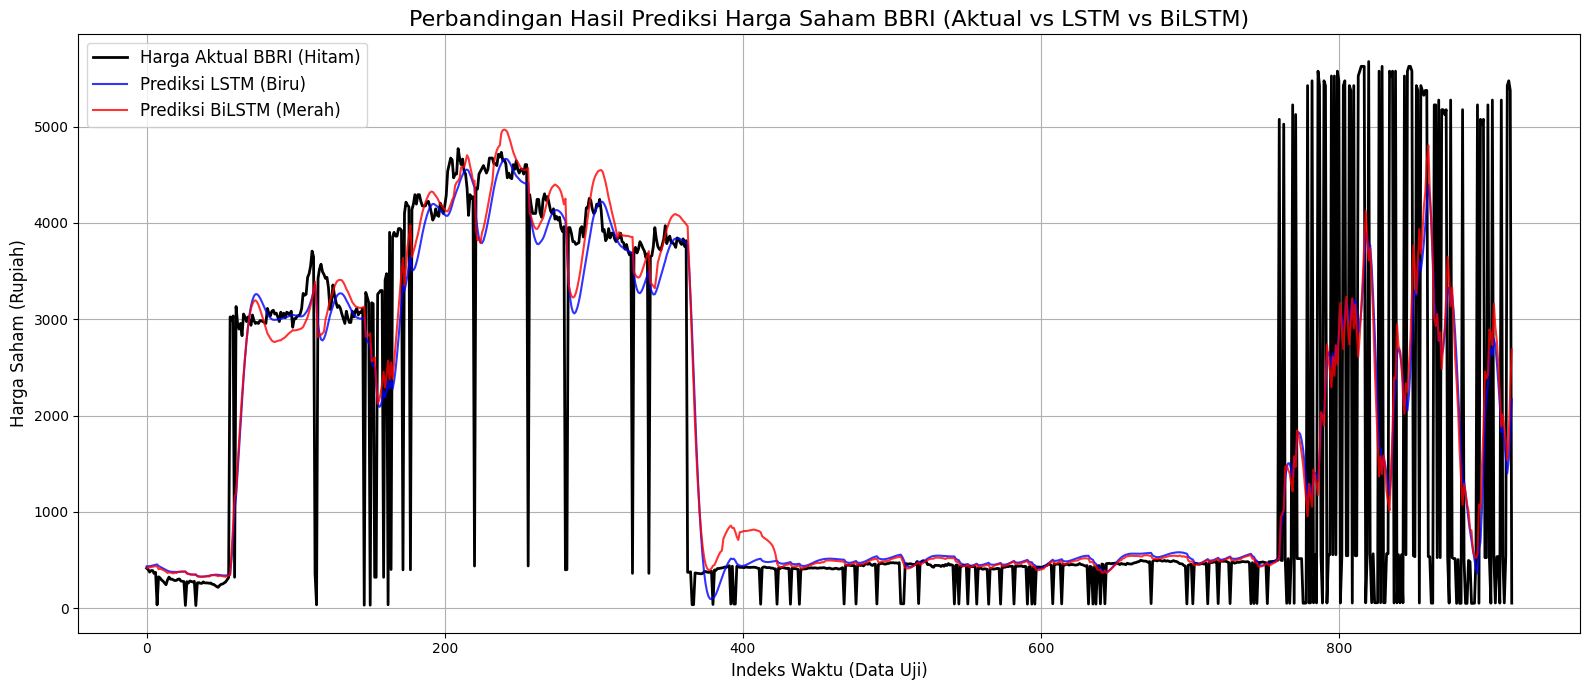

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. MENGHITUNG NILAI EVALUASI LSTM
# ==========================================================
# squared=False artinya kita mencari Root (Akar)-nya sehingga menjadi RMSE
rmse_lstm = np.sqrt(mean_squared_error(y_test_asli, prediksi_lstm))

# Dikali 100 agar bentuknya menjadi persen (%)
mape_lstm = mean_absolute_percentage_error(y_test_asli, prediksi_lstm) * 100

# ==========================================================
# 2. MENGHITUNG NILAI EVALUASI BiLSTM
# ==========================================================
rmse_bilstm = np.sqrt(mean_squared_error(y_test_asli, prediksi_bilstm))
mape_bilstm = mean_absolute_percentage_error(y_test_asli, prediksi_bilstm) * 100

print("======================================================")
print(" HASIL AKHIR PENELITIAN (EVALUASI MODEL)")
print("======================================================")
print("-> MODEL LSTM:")
print(f"   RMSE : Rp {rmse_lstm:,.2f}")
print(f"   MAPE : {mape_lstm:.2f}%\n")

print("-> MODEL BiLSTM:")
print(f"   RMSE : Rp {rmse_bilstm:,.2f}")
print(f"   MAPE : {mape_bilstm:.2f}%")
print("======================================================")

# ==========================================================
# 3. MEMBUAT VISUALISASI FINAL (GRAFIK PERBANDINGAN)
# ==========================================================
plt.figure(figsize=(16, 7))

# Sumbu X adalah Indeks Data Uji (bisa diganti dengan Tanggal dari DataFrame awal)
plt.plot(y_test_asli, label='Harga Aktual BBRI (Hitam)', color='black', linewidth=2)
plt.plot(prediksi_lstm, label='Prediksi LSTM (Biru)', color='blue', alpha=0.8)
plt.plot(prediksi_bilstm, label='Prediksi BiLSTM (Merah)', color='red', alpha=0.8)

plt.title('Perbandingan Hasil Prediksi Harga Saham BBRI (Aktual vs LSTM vs BiLSTM)', fontsize=16)
plt.xlabel('Indeks Waktu (Data Uji)', fontsize=12)
plt.ylabel('Harga Saham (Rupiah)', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True)
plt.tight_layout()

# Menampilkan grafik
plt.show()


--- 1. TABEL KESIMPULAN AKHIR KOMPARASI MODEL ---


,Model,Neuron Optimal,Dropout Optimal,Learning Rate,RMSE (Rp),MAPE (%)
0,LSTM,32,0.5,0.0001,1212.74,329.20
1,BiLSTM,32,0.3,0.0001,1217.95,334.19


Tabel telah disimpan ke 'Tabel_Komparasi_Final_BBRI.xlsx'


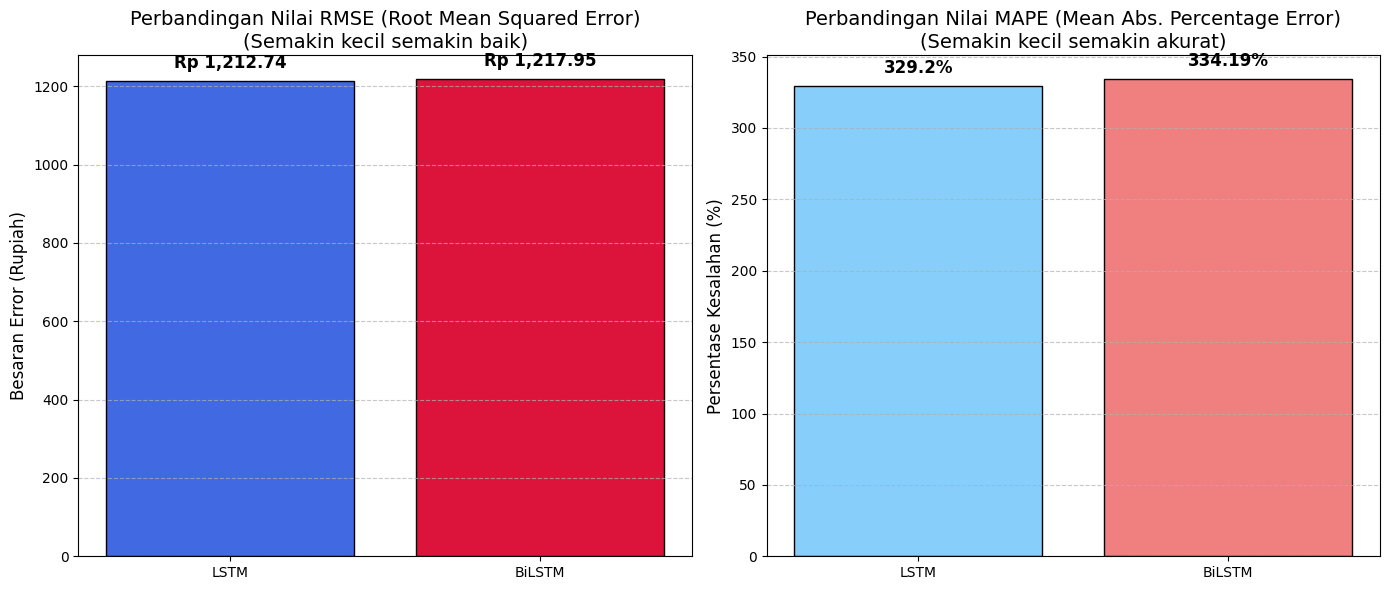


--- 2. KESIMPULAN HASIL PENELITIAN ---
- Berdasarkan eksperimen dengan bantuan Bayesian Optimization, model LSTM terbukti LEBIH UNGGUL.
- LSTM mencatat RMSE Rp 1,212.74 dan MAPE 329.20%, lebih rendah dari BiLSTM.
- Membuktikan bahwa pemrosesan satu arah sudah cukup ampuh tanpa beban komputasi tambahan dari BiLSTM.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. MENYUSUN TABEL KOMPARASI DARI VARIABEL TAHAP SEBELUMNYA
# ==========================================================
# Variabel rmse_lstm, mape_lstm, best_units_lstm, dll, berasal dari Tahap 8 dan Tahap 5
hasil_komparasi = {
    'Model': ['LSTM', 'BiLSTM'],
    'Neuron Optimal': [best_units_lstm, best_units_bilstm],
    'Dropout Optimal': [best_dropout_lstm, best_dropout_bilstm],
    'Learning Rate': [best_lr_lstm, best_lr_bilstm],
    'RMSE (Rp)': [round(rmse_lstm, 2), round(rmse_bilstm, 2)],
    'MAPE (%)': [round(mape_lstm, 2), round(mape_bilstm, 2)]
}

df_komparasi = pd.DataFrame(hasil_komparasi)

print("\n--- 1. TABEL KESIMPULAN AKHIR KOMPARASI MODEL ---")
display(df_komparasi)

# Simpan tabel ke Excel jika dibutuhkan
df_komparasi.to_excel('Tabel_Komparasi_Final_BBRI.xlsx', index=False)
print("Tabel telah disimpan ke 'Tabel_Komparasi_Final_BBRI.xlsx'")

# ==========================================================
# 2. MEMBUAT VISUALISASI BAR CHART (RMSE & MAPE)
# ==========================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart 1: RMSE (Kita panggil warnanya secara spesifik)
bars1 = axes[0].bar(df_komparasi['Model'], df_komparasi['RMSE (Rp)'],
                    color=['royalblue', 'crimson'], edgecolor='black')

axes[0].set_title('Perbandingan Nilai RMSE (Root Mean Squared Error)\n(Semakin kecil semakin baik)', fontsize=14)
axes[0].set_ylabel('Besaran Error (Rupiah)', fontsize=12)
# Menambahkan gridline di belakang
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Loop untuk menambahkan angka label persis di atas batang diagram RMSE
for bar in bars1:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02),
                 f'Rp {yval:,.2f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Bar chart 2: MAPE
bars2 = axes[1].bar(df_komparasi['Model'], df_komparasi['MAPE (%)'],
                    color=['lightskyblue', 'lightcoral'], edgecolor='black')

axes[1].set_title('Perbandingan Nilai MAPE (Mean Abs. Percentage Error)\n(Semakin kecil semakin akurat)', fontsize=14)
axes[1].set_ylabel('Persentase Kesalahan (%)', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Loop angka di batang diagram MAPE
for bar in bars2:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02),
                 f'{yval}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Mengatur jarak dan menampilkan
plt.tight_layout()
plt.show()

# ==========================================================
# 3. KESIMPULAN NARATIF (Fungsi IF-ELSE Penentu Pemenang)
# ==========================================================
print("\n--- 2. KESIMPULAN HASIL PENELITIAN ---")
if rmse_bilstm < rmse_lstm:
    print("- Berdasarkan eksperimen dengan bantuan Bayesian Optimization, model BiLSTM terbukti LEBIH UNGGUL.")
    print(f"- BiLSTM mencatat RMSE Rp {rmse_bilstm:,.2f} dan MAPE {mape_bilstm:.2f}%, lebih rendah dari LSTM.")
    print("- Membuktikan bahwa pemrosesan sequence dua arah bekerja lebih efektif pada prediksi saham.")
else:
    print("- Berdasarkan eksperimen dengan bantuan Bayesian Optimization, model LSTM terbukti LEBIH UNGGUL.")
    print(f"- LSTM mencatat RMSE Rp {rmse_lstm:,.2f} dan MAPE {mape_lstm:.2f}%, lebih rendah dari BiLSTM.")
    print("- Membuktikan bahwa pemrosesan satu arah sudah cukup ampuh tanpa beban komputasi tambahan dari BiLSTM.")